## Collect All `jpeg images` from Dataset Subdirectories

In [2]:
from pathlib import Path

# Path object to the dataset folder
dataset_image_path = Path("Helmet Detect")

# Recursively find all .jpg files in 'Helmet Detect' and all its subfolders (test, train, valid)
images_paths_lst = list(dataset_image_path.glob("**/*.jpg"))

## Dataset Cleanup: Remove `_png.rf.*` from Image Names

In [3]:
# Flag to track if we've already printed the "already desired format" message
already_desired_format = False

for path in images_paths_lst:
    
    # Check if filename contains "_png" (needs cleaning)
    if "_png" in path.stem:
        
        # Extract clean filename: remove everything after "_png" from the stem
        clean_name = path.stem.split("_png")[0]
        
        # Create new path with same parent directory, clean name and original extensions which is .jpg
        new_path = path.parent / (clean_name + path.suffix)
        
        # Rename only if the new name is different from the old name
        if path.name != new_path.name:
            
            # rename the file
            path.rename(new_path)
            print(f'Renamed: {path.name} -> {new_path.name}')
            
    elif not already_desired_format:
        print("Already desired format")
        already_desired_format = True

Already desired format


## Collect All `txt files` from Dataset Subdirectories

In [4]:
from pathlib import Path

# Path object to the dataset folder
dataset_label_path = Path("Helmet Detect")

# Recursively find all .txt files in 'Helmet Detect' and all its subfolders (test, train, valid)
labels_paths_lst = list(dataset_label_path.glob("**/*.txt"))

## Dataset Cleanup: Remove `_png.rf.*` from TXT Names

In [5]:
# Flag to track if we've already printed the "already desired format" message
already_desired_format = False

for path in labels_paths_lst:
    
    # Check if filename contains "_png" (needs cleaning)
    if "_png" in path.stem:
        
        # Extract clean filename: remove everything after "_png" from the stem
        clean_name = path.stem.split("_png")[0]
        
        # Create new path with same parent directory, clean name and original extensions which is .txt
        new_path = path.parent / (clean_name + path.suffix)
        
        # Rename only if the new name is different from the old name
        if path.name != new_path.name:
            
            # rename the file
            path.rename(new_path)
            print(f'Renamed: {path.name} -> {new_path.name}')
            
    elif not already_desired_format:
        print("Already desired format")
        already_desired_format = True

Already desired format


## Load YAML Dataset Config & Override Relative Paths to Absolute

In [6]:
import yaml

data_config = yaml.safe_load(open('Helmet Detect/data.yaml'))

# Override relative paths with absolute paths for YOLO training
data_config["train"] = 'Helmet Detect/train/images'
data_config["val"] = 'Helmet Detect/valid/images'
data_config["test"] = 'Helmet Detect/test/images'

data_config

{'train': 'Helmet Detect/train/images',
 'val': 'Helmet Detect/valid/images',
 'test': 'Helmet Detect/test/images',
 'nc': 2,
 'names': ['With Helmet', 'Without Helmet'],
 'roboflow': {'workspace': 'moeezs-workspace-gsui5',
  'project': 'helmet-detect-j6idy',
  'version': 1,
  'license': 'CC BY 4.0',
  'url': 'https://universe.roboflow.com/moeezs-workspace-gsui5/helmet-detect-j6idy/dataset/1'}}

In [7]:
class_names = data_config["names"]
class_names

['With Helmet', 'Without Helmet']

In [8]:
import glob

train_path = data_config['train']
images_paths_lst = list(dataset_image_path.glob("**/*.jpg"))
print(glob.glob(f"{train_path}/*.jpg")[:10])
print(30 * "_")
print(images_paths_lst[:5])

['Helmet Detect/train/images\\BikesHelmets10.jpg', 'Helmet Detect/train/images\\BikesHelmets100.jpg', 'Helmet Detect/train/images\\BikesHelmets101.jpg', 'Helmet Detect/train/images\\BikesHelmets104.jpg', 'Helmet Detect/train/images\\BikesHelmets106.jpg', 'Helmet Detect/train/images\\BikesHelmets107.jpg', 'Helmet Detect/train/images\\BikesHelmets108.jpg', 'Helmet Detect/train/images\\BikesHelmets11.jpg', 'Helmet Detect/train/images\\BikesHelmets110.jpg', 'Helmet Detect/train/images\\BikesHelmets111.jpg']
______________________________
[WindowsPath('Helmet Detect/test/images/BikesHelmets0.jpg'), WindowsPath('Helmet Detect/test/images/BikesHelmets102.jpg'), WindowsPath('Helmet Detect/test/images/BikesHelmets105.jpg'), WindowsPath('Helmet Detect/test/images/BikesHelmets109.jpg'), WindowsPath('Helmet Detect/test/images/BikesHelmets114.jpg')]


## Visualize YOLO Training Samples with Bounding Boxes


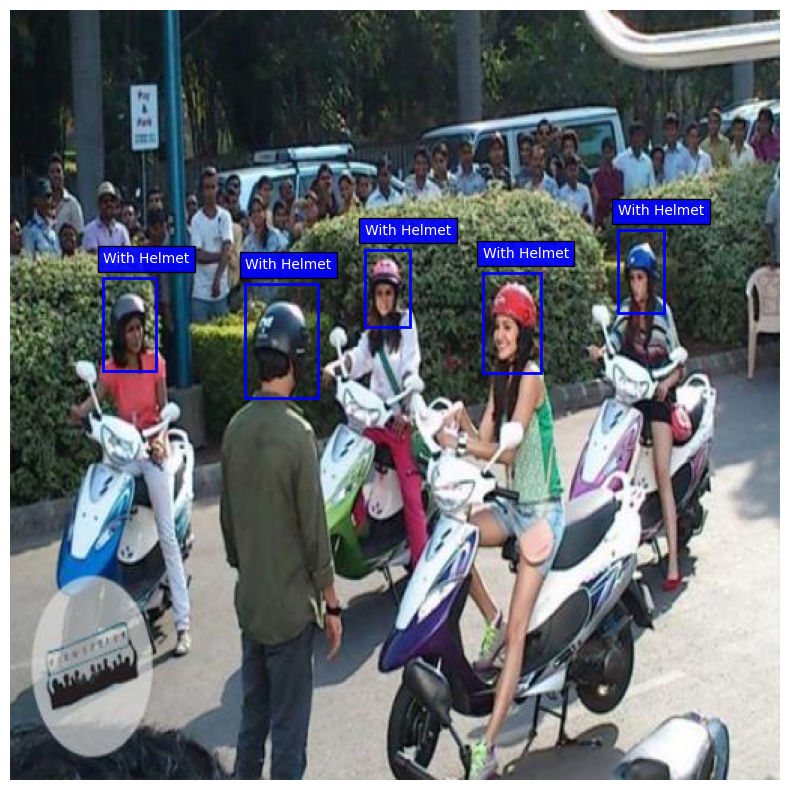

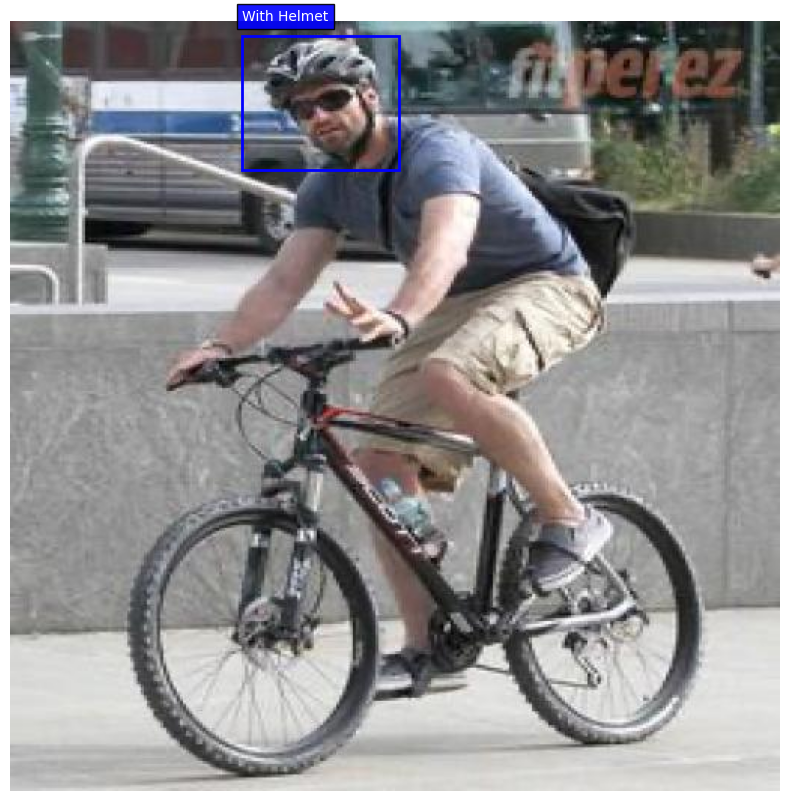

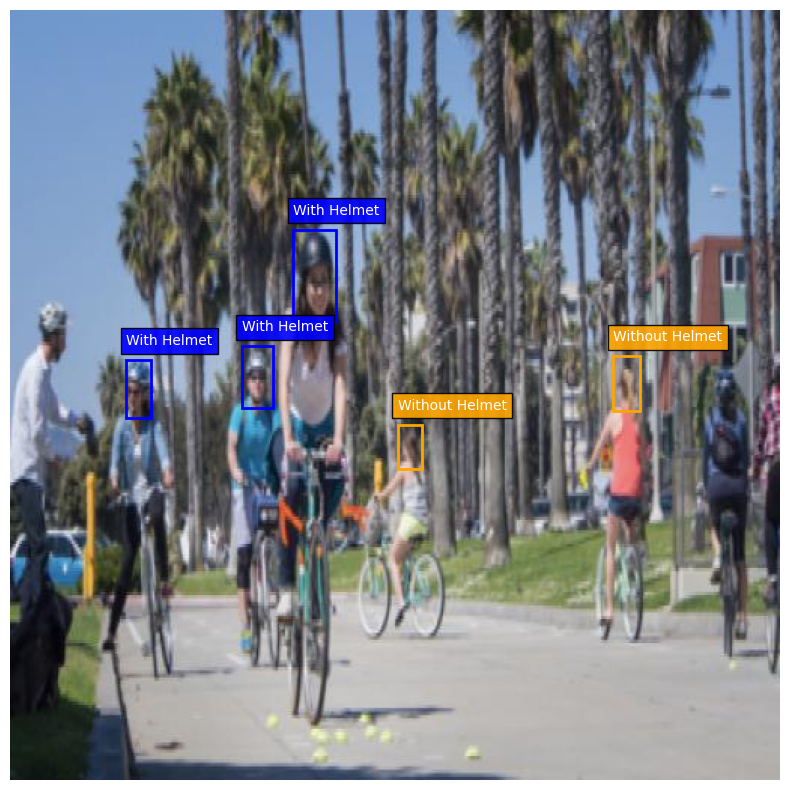

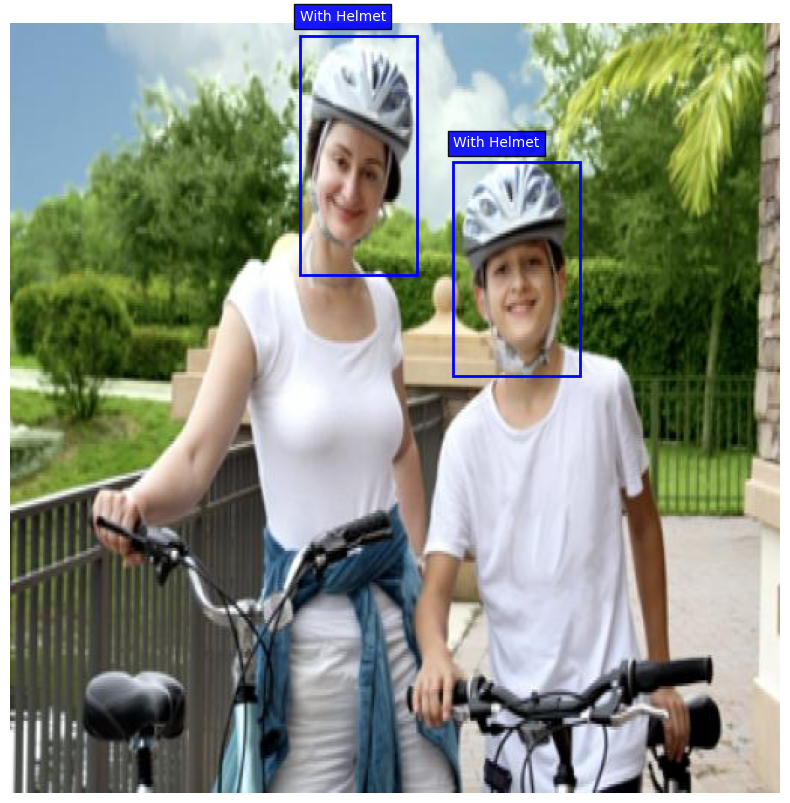

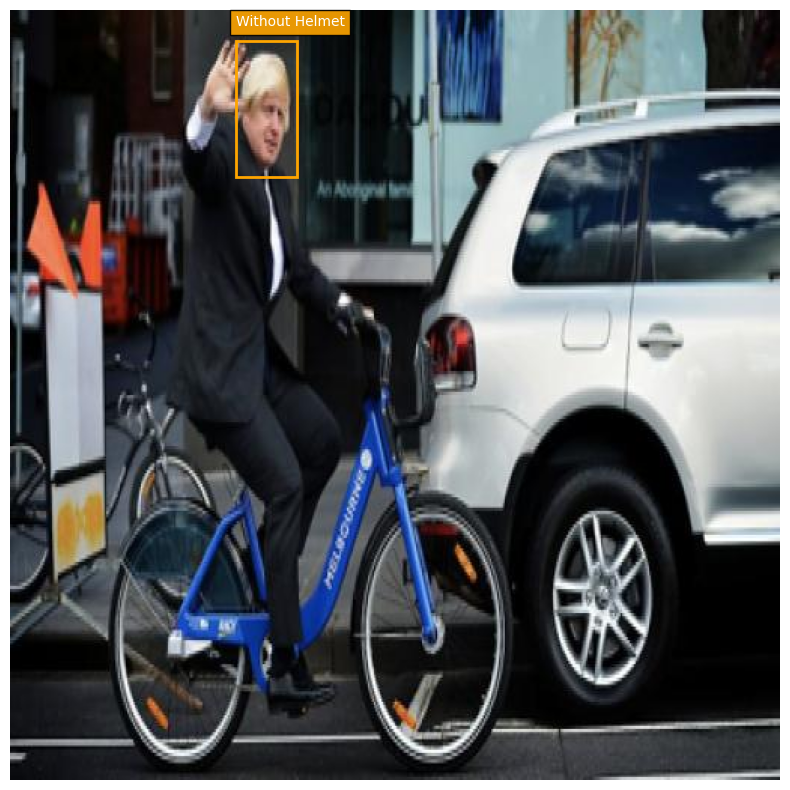

In [29]:
import glob
import cv2
import matplotlib.pyplot as plt
import os
from pathlib import Path
import random

# Get class names from YAML config
class_names = data_config["names"]

# Get training images directory path
train_path = data_config['train']

all_images_path = glob.glob(f"{train_path}/*.jpg")
# Load first 10 sample images from training folder
sample_images = random.choices(all_images_path, k=5)

for img_path in sample_images:
    
    # Load and Convert image (BGR to RGB)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Get image dimensions: height, width (ignore channels)
    h, w, _ = img.shape
    
    # Convert string path to Path object for easy manipulation
    image_path = Path(img_path)
    
    # Goes from: train/images/BikesHelmets2.jpg → train/labels/BikesHelmets2.txt
    label_path = image_path.parent.parent / "labels" / (image_path.stem + ".txt")
            
    # If label exists: draw bounding boxes
    if os.path.exists(label_path):
        plt.figure(figsize=(10, 10))
        plt.imshow(img)
        
        # Gets the current axes (canvas) so you can draw on it.
        ax = plt.gca()
        
        # Parse YOLO format: class x_center, y_center, width, height (normalized 0-1)
        with open(label_path) as f:
            for line in f:
                
                # Split line into 5 numbers: class_id, center_x, center_y, box_width, box_height
                # line.split() -> list of strings -> ["0", "0.5", "0.3", "0.2", "0.1"]
                # map(float, line.split()) -> list of floats -> [0.0, 0.5, 0.3, 0.2, 0.1]
                cls, xc, yc, bw, bh = map(float, line.split())
                
                # Scale normalized YOLO coordinates to absolute pixel values
                # (center_x, center_y, width, height) -> (x1, y1, x2, y2)
                
                # Left edge = (center - half_width) × image_width
                x1 = (xc - bw/2) * w

                # Right edge = (center + half_width) × image_width  
                x2 = (xc + bw/2) * w

                # Top edge = (center - half_height) × image_height
                y1 = (yc - bh/2) * h

                # Bottom edge = (center + half_height) × image_height
                y2 = (yc + bh/2) * h
                
                # Color coding: Blue for helmet (class 0), Orange for no-helmet (class 1)
                if int(cls) == 0:
                    color = "blue"
                else:
                    color = "orange"
                
                # Create rectangle: top-left corner (x1,y1), width (x2-x1), height (y2-y1)
                rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, 
                                     fill=False,        # Don't fill inside, just show outline 
                                     edgecolor=color,   # Border color (unique per class)
                                     linewidth=2)
                
                # Add the rectangle to the axes (image) so it appears on the plot (Draw the rectangle on the canvas)
                ax.add_patch(rect)
                
                # Draw class label with colored background above bounding box
                plt.text(x1, y1-10,                    # Position: above box (10 pixels up)
                         class_names[int(cls)],
                         color='white',
                         fontsize=10,         
                         bbox=dict(facecolor=color,    # Box background: same color as bounding box
                                   alpha=0.9))

        plt.axis('off')
        plt.show()

In [ ]:
from ultralytics import YOLO

model = YOLO('yolov8n.pt')

results = model.train(
    data=r"Helmet Detect\data.yaml",
    epochs=50,
    batch=8,
    imgsz=640
)

New https://pypi.org/project/ultralytics/8.4.70 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.66  Python-3.12.7 torch-2.5.1+cu124 CUDA:0 (NVIDIA GeForce RTX 3050 Ti Laptop GPU, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=Helmet Detect\data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_